🎯 Project Goal

Build a Probability of Default (PD) model using historical LendingClub loan data to predict whether a borrower will default.

In [ ]:
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/Colab Notebooks/archive.zip'
extract_dir = '/tmp/extracted_archive'

# Create the directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Archive extracted to: {extract_dir}")
print("Contents of the extracted archive:")
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        print(os.path.join(root, file))

Archive extracted to: /tmp/extracted_archive
Contents of the extracted archive:
/tmp/extracted_archive/loan.csv
/tmp/extracted_archive/LCDataDictionary.xlsx


In [ ]:
import pandas as pd

file_path = '/tmp/extracted_archive/loan.csv'
df = pd.read_csv(file_path)
display(df.head())

/tmp/ipython-input-230/2052945210.py:4: DtypeWarning: Columns (19,47,55,112,123,124,125,128,129,130,133,139,140,141) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print(df.shape)
df.columns

(2260668, 145)


Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='object', length=145)

In [ ]:
df['loan_status'].value_counts()

,count
loan_status,
Fully Paid,1041952
Current,919695
Charged Off,261655
Late (31-120 days),21897
In Grace Period,8952
Late (16-30 days),3737
Does not meet the credit policy. Status:Fully Paid,1988
Does not meet the credit policy. Status:Charged Off,761
Default,31


In [ ]:
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]

df['default'] = (df['loan_status'] == 'Charged Off').astype(int)

print(df.shape)
print("Default rate:", df['default'].mean())

(1303607, 146)
Default rate: 0.2007161667588468


/tmp/ipython-input-230/79580869.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['default'] = (df['loan_status'] == 'Charged Off').astype(int)


In [ ]:
df = df.sample(n=120000, random_state=42)

print(df.shape)

(120000, 146)


In [ ]:
drop_cols = [
    'id','member_id',
    'loan_status',
    'issue_d',
    'total_pymnt',
    'total_rec_prncp',
    'total_rec_int',
    'recoveries',
    'collection_recovery_fee',
    'last_pymnt_d',
    'last_pymnt_amnt'
]

df = df.drop(columns=drop_cols, errors='ignore')

In [ ]:
selected_features = [
    'loan_amnt',
    'term',
    'int_rate',
    'installment',
    'grade',
    'annual_inc',
    'dti',
    'delinq_2yrs',
    'inq_last_6mths',
    'open_acc',
    'pub_rec',
    'revol_bal',
    'revol_util',
    'total_acc',
    'collections_12_mths_ex_med',
    'acc_now_delinq',
    'emp_length',
    'home_ownership',
    'verification_status',
    'purpose',
    'default'
]

df_model = df[selected_features].copy()

df_model.shape

(120000, 21)

selected features based on underwriting logic: loan characteristics, borrower capacity, credit history indicators, and stability variables

In [ ]:
df_model.isna().mean().sort_values(ascending=False)

,0
emp_length,0.057533
revol_util,0.000683
dti,0.000233
collections_12_mths_ex_med,0.000075
loan_amnt,0.000000
grade,0.000000
installment,0.000000
int_rate,0.000000
term,0.000000
inq_last_6mths,0.000000


In [ ]:
df_model.dtypes

,0
loan_amnt,int64
term,float64
int_rate,float64
installment,float64
grade,object
annual_inc,float64
dti,float64
delinq_2yrs,float64
inq_last_6mths,float64
open_acc,float64


In [ ]:
df_model['emp_length'].unique()

array(['10+ years', '6 years', '8 years', '3 years', '2 years', nan,
       '1 year', '< 1 year', '4 years', '5 years', '7 years', '9 years'],
      dtype=object)

In [ ]:
df_model['emp_length'] = df_model['emp_length'].replace({
    '< 1 year': 0,
    '10+ years': 10
})

df_model['emp_length'] = df_model['emp_length'].str.extract(r'(\d+)')
df_model['emp_length'] = df_model['emp_length'].astype(float)

In [ ]:
df_model.dtypes

,0
loan_amnt,int64
term,float64
int_rate,float64
installment,float64
grade,object
annual_inc,float64
dti,float64
delinq_2yrs,float64
inq_last_6mths,float64
open_acc,float64


PD Model building

In [ ]:
from sklearn.model_selection import train_test_split

X = df_model.drop('default', axis=1)
y = df_model['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, classification_report

# X/y
X = df_model.drop('default', axis=1)
y = df_model['default']

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# columns
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(include=['float64','int64']).columns.tolist()

# preprocess with imputers
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ]
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("ROC AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred, digits=3))

ROC AUC: 0.6998288147532814
              precision    recall  f1-score   support

           0      0.880     0.620     0.728     19165
           1      0.307     0.665     0.420      4835

    accuracy                          0.629     24000
   macro avg      0.593     0.643     0.574     24000
weighted avg      0.765     0.629     0.666     24000



This project builds a Probability of Default (PD) model using historical LendingClub loan data. After filtering loans with finalized outcomes and removing forward-looking variables to prevent data leakage, a logistic regression model was trained using borrower characteristics, loan attributes, and credit history indicators. The model achieved an ROC-AUC of 0.70, indicating reasonable discriminatory power. At the default classification threshold of 0.5, the model captures approximately 66% of defaulters, demonstrating strong recall performance for risk identification. The results suggest that the model can effectively distinguish higher-risk borrowers, though threshold optimization could further improve risk targeting.

In [ ]:
import numpy as np
import pandas as pd

#dataframe
results = pd.DataFrame({
    'y_true': y_test,
    'y_prob': y_prob
})

results = results.sort_values('y_prob')

results['cum_good'] = (results['y_true'] == 0).cumsum() / (results['y_true'] == 0).sum()
results['cum_bad'] = (results['y_true'] == 1).cumsum() / (results['y_true'] == 1).sum()

# KS
ks = np.max(np.abs(results['cum_bad'] - results['cum_good']))
print("KS Statistic:", ks)

KS Statistic: 0.28946230026027175


In [ ]:
from sklearn.metrics import precision_recall_fscore_support

thresholds = np.linspace(0.1,0.6,20)

for t in thresholds:
    pred = (y_prob >= t).astype(int)
    p,r,f,_ = precision_recall_fscore_support(y_test,pred,average='binary')
    print(f"Threshold {t:.2f} | Precision {p:.3f} | Recall {r:.3f}")

Threshold 0.10 | Precision 0.202 | Recall 1.000
Threshold 0.13 | Precision 0.202 | Recall 0.999
Threshold 0.15 | Precision 0.206 | Recall 0.996
Threshold 0.18 | Precision 0.211 | Recall 0.988
Threshold 0.21 | Precision 0.218 | Recall 0.976
Threshold 0.23 | Precision 0.224 | Recall 0.964
Threshold 0.26 | Precision 0.228 | Recall 0.952
Threshold 0.28 | Precision 0.234 | Recall 0.940
Threshold 0.31 | Precision 0.239 | Recall 0.922
Threshold 0.34 | Precision 0.247 | Recall 0.901
Threshold 0.36 | Precision 0.255 | Recall 0.877
Threshold 0.39 | Precision 0.262 | Recall 0.843
Threshold 0.42 | Precision 0.272 | Recall 0.805
Threshold 0.44 | Precision 0.282 | Recall 0.760
Threshold 0.47 | Precision 0.293 | Recall 0.719
Threshold 0.49 | Precision 0.304 | Recall 0.676
Threshold 0.52 | Precision 0.317 | Recall 0.624
Threshold 0.55 | Precision 0.333 | Recall 0.569
Threshold 0.57 | Precision 0.351 | Recall 0.510
Threshold 0.60 | Precision 0.369 | Recall 0.447


The model achieved a KS statistic of 0.29 and ROC-AUC of 0.70, indicating reasonable discriminatory power. Threshold analysis reveals the expected tradeoff between recall and precision. At lower thresholds (e.g., 0.30–0.40), recall exceeds 80%, enabling effective identification of high-risk borrowers, albeit with reduced precision. In a credit risk context where default losses are significantly larger than opportunity costs, a lower cutoff may be economically optimal.

In [ ]:
results['risk_decile'] = pd.qcut(results['y_prob'], 10, labels=False)

pd.crosstab(results['risk_decile'], results['y_true'], normalize='index')

y_true,0,1
risk_decile,,
0,0.951250,0.048750
1,0.918750,0.081250
2,0.889167,0.110833
3,0.855833,0.144167
4,0.828333,0.171667
5,0.804583,0.195417
6,0.781667,0.218333
7,0.725833,0.274167
8,0.683750,0.316250


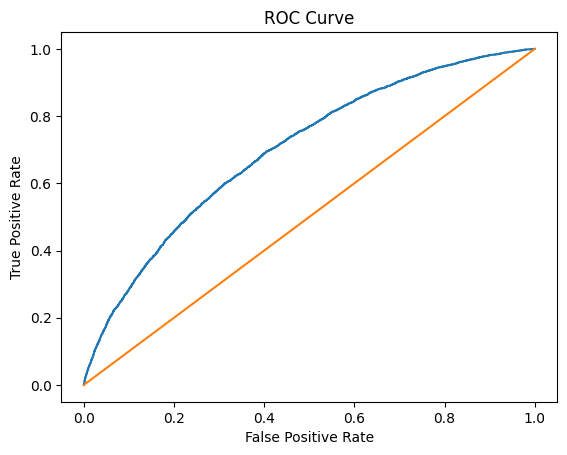

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

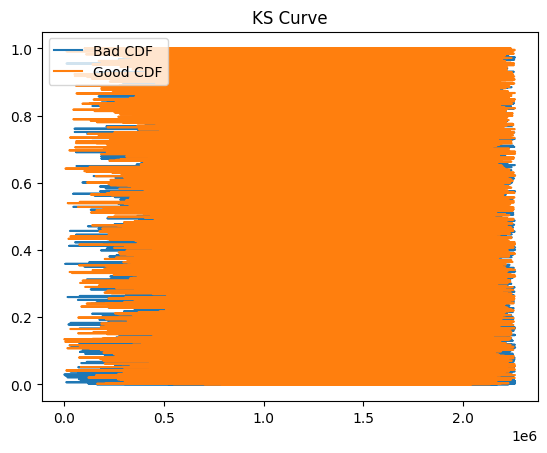

In [ ]:
plt.figure()
plt.plot(results['cum_bad'], label='Bad CDF')
plt.plot(results['cum_good'], label='Good CDF')
plt.title("KS Curve")
plt.legend()
plt.show()

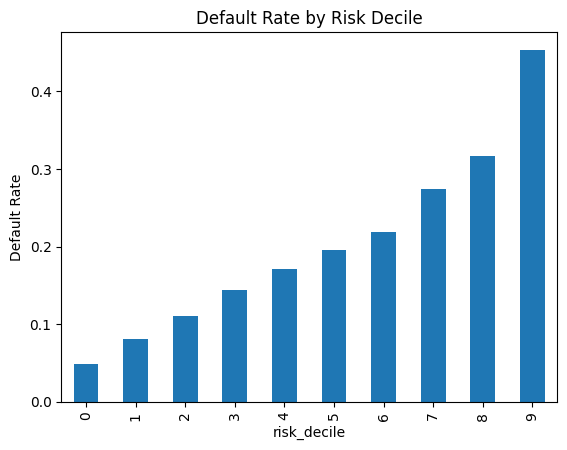

In [ ]:
decile_default = results.groupby('risk_decile')['y_true'].mean()

plt.figure()
decile_default.plot(kind='bar')
plt.title("Default Rate by Risk Decile")
plt.ylabel("Default Rate")
plt.show()